### Temporal integration of ODE with PINN

Consider the numerical approximation an ODE
$$
\frac{dy}{dt}=\alpha y,\quad t\in[0,T],
$$
with the initial condition $y(0)=1$.

In [33]:
import math
import torch
from torch import nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [34]:
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

# problem parameter
alpha = 2.0 
T=1.0

# training parameters
n_iters = 10000
batch_size = 256 # number of random collocation points per iteration
print_every = 500

lr = 1e-3 # learning rate

# Penalty parameter for the initial condition
w_ic = 10.0

Using cuda device


### Define the solution model 
Let $a_\theta(t)$ be a feedforward artificial neural network, where $\theta$ includes all model parameters. 
We define a solution model as
$$
y_\theta(t)=a_\theta(t).
$$
The model needs to learn the initial condition. 

We can also define a solution model as
$$
y_\theta(t)=1+ta_\theta(t).
$$
where the initial condition is satisfied exactly, i.e., $y_\theta(0)=1$. We consider the first option here.

In [35]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MLP(hidden=32, depth=3).to(device)

### Define the training set.

Let $\{t_i\}_{i=1}^N$ be a set of collocation points on the interval $[0,1]$. $t_i$ can be selected randomly or specified deterministically. We here use uniformly distributed random samples.

The loss of PINN is defined as 
$$
L(\theta)=\frac{1}{N}\sum_{i=1}^N(y'_\theta(t_{i})-\alpha y(t_{i}))^2 + \beta(y_\theta(0)-1)^2,
$$
where $\beta>0$ is a penalty parameter, $y'_\theta(t_{i})-\alpha y(t_{i})$ is the residual of the ODE, and $y_\theta(0)-1$ is the residual of the initial codition.  

We seek the optimal parameter by minimizing the loss function:
$$
\theta^*=\text{argmin}_\theta L(\theta).
$$

In [36]:
def pinn_loss(model: nn.Module, t_interior: torch.Tensor) -> torch.Tensor:
    """
    t_interior: shape (N,1), requires_grad will be enabled to compute dy/dt.
    """
    # Enable autograd for derivative wrt t
    t_interior = t_interior.clone().detach().requires_grad_(True)

    y = model(t_interior)  # (N,1)

    # dy/dt
    dy_dt = torch.autograd.grad(
        outputs=y,
        inputs=t_interior,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]

    # ODE residual: y' - a y 
    r = dy_dt - alpha * y
    loss_ode = torch.mean(r**2)

    # Initial condition: y(0)=1
    t0 = torch.zeros((1, 1), device=device, dtype=t_interior.dtype)
    y0 = model(t0)
    loss_ic = (y0 - 1.0) ** 2

    return loss_ode + w_ic * loss_ic

In [37]:
optimizer = optim.Adam(model.parameters(), lr=lr)

In [39]:
# -----------------------------
# Training loop
# -----------------------------
model.train()
for it in range(1, n_iters + 1):
    # Uniform random samples on [0,T]
    t_batch = torch.rand((batch_size, 1), device=device)*T

    loss = pinn_loss(model, t_batch)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if it % print_every == 0 or it == 1:
        print(f"iter {it:5d} | loss = {loss.item():.3e}")

iter     1 | loss = 1.374e+01
iter   500 | loss = 9.565e-01
iter  1000 | loss = 4.805e-03
iter  1500 | loss = 5.548e-04
iter  2000 | loss = 2.867e-04
iter  2500 | loss = 1.019e-04
iter  3000 | loss = 7.815e-05
iter  3500 | loss = 6.219e-05
iter  4000 | loss = 5.936e-05
iter  4500 | loss = 1.065e-03
iter  5000 | loss = 4.532e-04
iter  5500 | loss = 1.491e-03
iter  6000 | loss = 5.976e-04
iter  6500 | loss = 4.690e-05
iter  7000 | loss = 5.503e-04
iter  7500 | loss = 5.625e-04
iter  8000 | loss = 6.557e-05
iter  8500 | loss = 3.813e-04
iter  9000 | loss = 3.859e-04
iter  9500 | loss = 3.643e-05
iter 10000 | loss = 3.061e-04


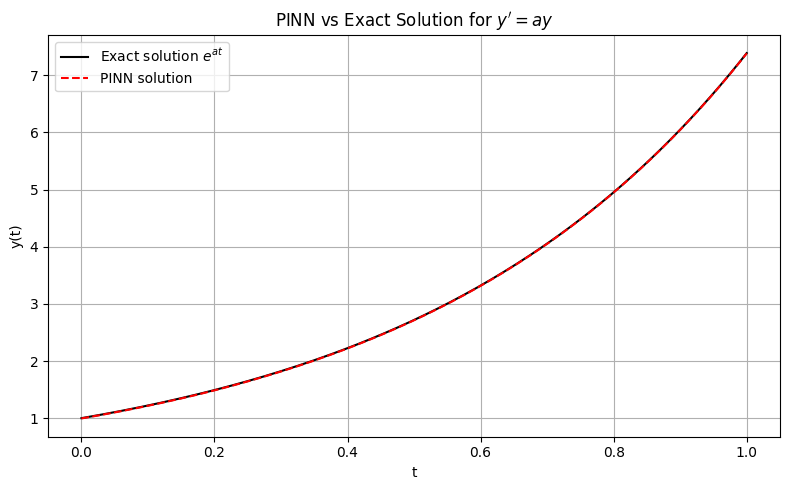

In [40]:
# -----------------------------
# Evaluation: compare to exact solution on a uniform mesh
# -----------------------------
model.eval()
with torch.no_grad():
    n_grid = 201
    t_grid = torch.linspace(0.0, T, n_grid, device=device).view(-1, 1)
    y_pred = model(t_grid).view(-1)

    # Exact: y(t) = exp(a t)
    y_exact = torch.exp(alpha * t_grid).view(-1)

    max_err = torch.max(torch.abs(y_pred - y_exact)).item()
    l2_err = torch.sqrt(torch.mean((y_pred - y_exact) ** 2)).item()

# Move tensors to CPU and convert to numpy
t_plot = t_grid.cpu().numpy().flatten()
y_pred_plot = y_pred.cpu().numpy().flatten()
y_exact_plot = y_exact.cpu().numpy().flatten()

plt.figure(figsize=(8, 5))
plt.plot(t_plot, y_exact_plot, 'k-', label='Exact solution $e^{at}$')
plt.plot(t_plot, y_pred_plot, 'r--', label='PINN solution')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("PINN vs Exact Solution for $y' = a y$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Spectral Bias
Spectral bias (also called frequency bias) is the empirically observed tendency of standard neural networks trained with gradient-based optimization (e.g., SGD/Adam) to learn low-frequency (smooth) components of a target function first, while high-frequency (rapidly oscillating) components are learned later (or sometimes poorly). This is often observed in regression. 

1. Typical MLPs + standard initialization + gradient descent behave like smooth function approximators early in training.
2. The gradients and parameter updates tend to reduce error in the “easy/smooth” directions first, so low-frequency modes converge faster than high-frequency modes.

### A simple numerical demonstration
We fit the following function:
$$
f(x)=\sin(x)+0.5\sin(10x)+0.2\sin(30x),\quad x\in[0,2\pi].
$$
If spectral bias exists, we will see: The network quickly fits $\sin(x)$, then gradually fits $\sin(10x)$, and only later starts matching $\sin(30x)$.

In [42]:
# Training settings
#steps = 20000
#batch_size = 512
#print_every = 500
#checkpoints = [0, 50, 200, 800, 2000, 5000, 10000, 20000]  # times to snapshot spectra/predictions

# Domain: periodic [0, 2pi)
N_grid = 2048
x_grid = torch.linspace(0.0, 2 * math.pi, N_grid + 1)[:-1].view(-1, 1).to(device)  # drop endpoint for periodic FFT

# Target function with mixed frequencies
def f_target(x):
    return (torch.sin(x)
            + 0.5 * torch.sin(10.0 * x)
            + 0.2 * torch.sin(30.0 * x))

y_true = f_target(x_grid)

In [43]:
# ----------------------------
# 3) Helpers: FFT magnitude
# ----------------------------
def fft_mag(y):
    """
    y: torch tensor shape (N,1) on device
    Returns numpy arrays (freq_indices, magnitude)
    """
    y_np = y.detach().cpu().numpy().squeeze()  # shape (N,)
    Y = np.fft.rfft(y_np)                      # real FFT
    mag = np.abs(Y) / len(y_np)                # scale
    k = np.arange(len(mag))                    # frequency bin indices
    return k, mag
    
# True spectrum
k_true, mag_true = fft_mag(y_true)

In [44]:
# ----------------------------
# 3) Training function
# ----------------------------
def train_and_snapshot(model, steps=5000, batch_size=512, lr=1e-3,
                       checkpoints=(0, 50, 200, 800, 2000, 5000, 10000, 20000),
                       print_every=500, title="model"):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    snap_pred = {}
    snap_fft = {}

    model.train()

    # step 0 snapshot
    with torch.no_grad():
        y0 = model(x_grid)
    snap_pred[0] = y0.detach().cpu().numpy().squeeze()
    snap_fft[0] = fft_mag(y0)

    for step in range(1, steps + 1):
        xb = (2 * math.pi) * torch.rand(batch_size, 1, device=device)
        yb = f_target(xb)

        pred = model(xb)
        loss = torch.mean((pred - yb) ** 2)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if step % print_every == 0:
            print(f"[{title}] step {step:5d} | loss {loss.item():.3e}")

        if step in checkpoints:
            model.eval()
            with torch.no_grad():
                yhat = model(x_grid)
            snap_pred[step] = yhat.detach().cpu().numpy().squeeze()
            snap_fft[step] = fft_mag(yhat)
            model.train()

    return snap_pred, snap_fft

steps = 20000
checkpoints = (0, 50, 200, 800, 2000, 5000, 10000, 20000)

vanilla = MLP(hidden=64, depth=4).to(device)
snap_pred_v, snap_fft_v = train_and_snapshot(
    vanilla, steps=steps, checkpoints=checkpoints, title="Vanilla"
)

[Vanilla] step   500 | loss 1.535e-01
[Vanilla] step  1000 | loss 1.369e-01
[Vanilla] step  1500 | loss 1.343e-01
[Vanilla] step  2000 | loss 1.364e-01
[Vanilla] step  2500 | loss 1.423e-01
[Vanilla] step  3000 | loss 1.401e-01
[Vanilla] step  3500 | loss 1.254e-01
[Vanilla] step  4000 | loss 1.190e-01
[Vanilla] step  4500 | loss 1.057e-01
[Vanilla] step  5000 | loss 1.017e-01
[Vanilla] step  5500 | loss 8.884e-02
[Vanilla] step  6000 | loss 4.969e-02
[Vanilla] step  6500 | loss 2.180e-02
[Vanilla] step  7000 | loss 1.390e-02
[Vanilla] step  7500 | loss 1.229e-02
[Vanilla] step  8000 | loss 1.118e-02
[Vanilla] step  8500 | loss 1.057e-02
[Vanilla] step  9000 | loss 9.045e-03
[Vanilla] step  9500 | loss 7.661e-03
[Vanilla] step 10000 | loss 5.748e-03
[Vanilla] step 10500 | loss 4.819e-03
[Vanilla] step 11000 | loss 3.562e-03
[Vanilla] step 11500 | loss 3.891e-03
[Vanilla] step 12000 | loss 3.537e-03
[Vanilla] step 12500 | loss 3.014e-03
[Vanilla] step 13000 | loss 2.130e-03
[Vanilla] st

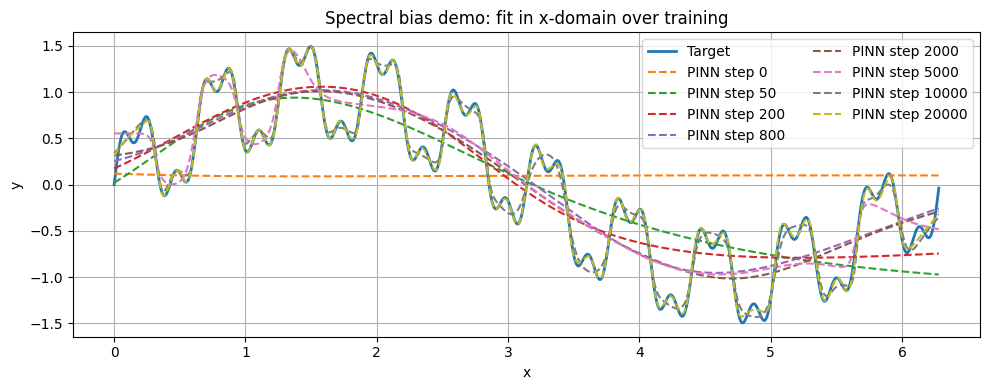

In [20]:
# Final true signal for plotting
x_np = x_grid.detach().cpu().numpy().squeeze()
y_true_np = y_true.detach().cpu().numpy().squeeze()

# ----------------------------
# 5) Plot A: function fit over time
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(x_np, y_true_np, label="Target", linewidth=2)

for t in checkpoints:
    plt.plot(x_np, snap_pred_v[t], linestyle="--", label=f"PINN step {t}")

plt.title("Spectral bias demo: fit in x-domain over training")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

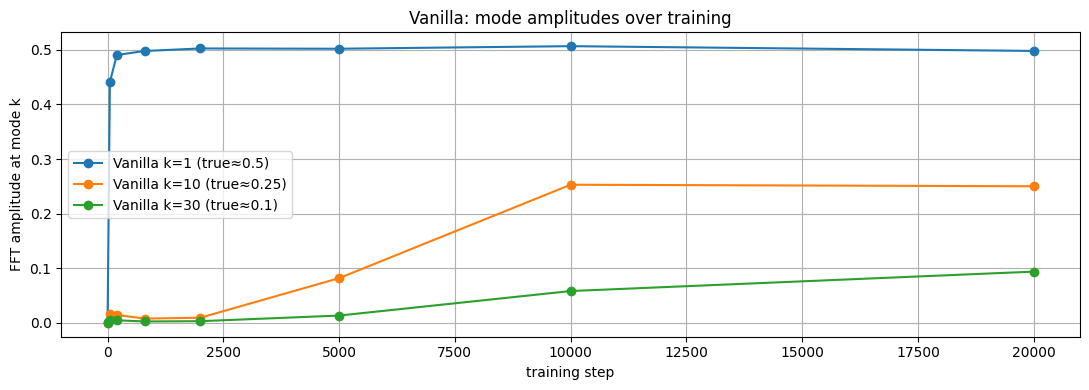

In [21]:
# ----------------------------
# 7) Optional: track specific mode errors (k=1,10,30)
# ----------------------------
def mode_amp(mag, kk):
    return mag[kk] if kk < len(mag) else 0.0

modes = [1, 10, 30]
amp_true = {kk: mode_amp(mag_true, kk) for kk in modes}

times = list(checkpoints)
amps_v = {kk: [mode_amp(snap_fft_v[t][1], kk) for t in checkpoints] for kk in modes}

plt.figure(figsize=(11, 4))
for kk in modes:
    plt.plot(times, amps_v[kk], marker="o", label=f"Vanilla k={kk} (true≈{amp_true[kk]:.3g})")
plt.title("Vanilla: mode amplitudes over training")
plt.xlabel("training step")
plt.ylabel("FFT amplitude at mode k")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Alleviate spectral bias using random Fourier features

Replace input $x\in\mathbb{R}$ with features
$$
\phi(x)=[\sin(Bx),\,\cos(Bx)],
$$
where $B\in\mathbb{R}^{n\times 1}$ has entries sampled from $\mathscr{N}(0,\sigma^2)$. Larger $\sigma$ gives higher-frequency capacity.

In [45]:
class RandomFourierFeatures(nn.Module):
    """
    phi(x) = [sin(Bx), cos(Bx)] with fixed random B
    x: (N,1) -> features: (N, 2*m)
    """
    def __init__(self, m=128, sigma=10.0):
        super().__init__()
        B = torch.randn(m, 1) * sigma
        self.register_buffer("B", B)  # fixed, not trained

    def forward(self, x):
        # (N,1) -> (N,m)
        proj = x @ self.B.t()
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

class RFF_MLP(nn.Module):
    def __init__(self, m=128, sigma=10.0, width=128, depth=3):
        super().__init__()
        self.rff = RandomFourierFeatures(m=m, sigma=sigma)
        in_dim = 2 * m
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        z = self.rff(x)
        return self.net(z)

In [46]:
# RFF settings: increase sigma if you want even more high-frequency capacity
rff_model = RFF_MLP(m=64, sigma=10.0, width=128, depth=3)
snap_pred_r, snap_fft_r = train_and_snapshot(
    rff_model, steps=steps, checkpoints=checkpoints, title="RFF"
)

[RFF] step   500 | loss 5.566e-06
[RFF] step  1000 | loss 3.428e-06
[RFF] step  1500 | loss 1.500e-04
[RFF] step  2000 | loss 7.804e-05
[RFF] step  2500 | loss 8.776e-06
[RFF] step  3000 | loss 3.299e-05
[RFF] step  3500 | loss 6.063e-06
[RFF] step  4000 | loss 1.294e-04
[RFF] step  4500 | loss 2.268e-04
[RFF] step  5000 | loss 4.166e-06
[RFF] step  5500 | loss 6.516e-06
[RFF] step  6000 | loss 1.271e-04
[RFF] step  6500 | loss 8.930e-05
[RFF] step  7000 | loss 2.141e-05
[RFF] step  7500 | loss 4.819e-06
[RFF] step  8000 | loss 1.249e-05
[RFF] step  8500 | loss 1.012e-05
[RFF] step  9000 | loss 1.231e-06
[RFF] step  9500 | loss 7.330e-05
[RFF] step 10000 | loss 2.869e-05
[RFF] step 10500 | loss 1.189e-05
[RFF] step 11000 | loss 5.323e-05
[RFF] step 11500 | loss 1.839e-05
[RFF] step 12000 | loss 3.563e-05
[RFF] step 12500 | loss 8.807e-06
[RFF] step 13000 | loss 1.517e-04
[RFF] step 13500 | loss 1.323e-05
[RFF] step 14000 | loss 1.204e-05
[RFF] step 14500 | loss 1.025e-05
[RFF] step 150

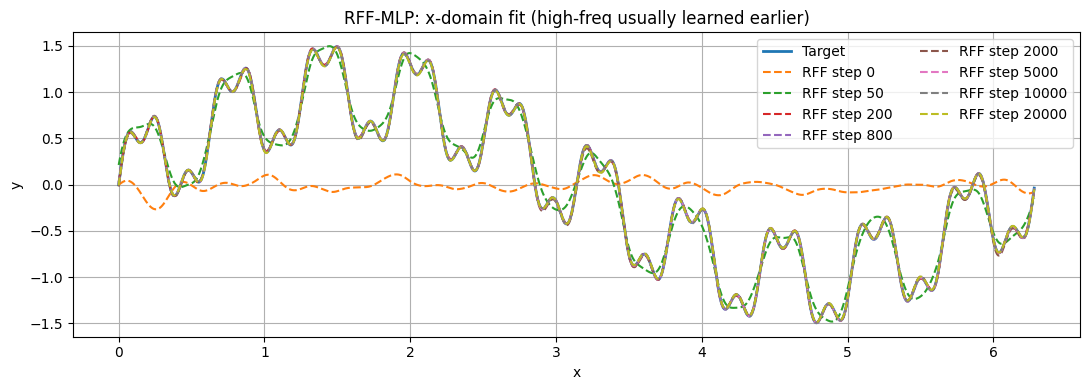

In [24]:
plt.figure(figsize=(11, 4))
plt.plot(x_np, y_true_np, linewidth=2, label="Target")

for t in checkpoints:
    plt.plot(x_np, snap_pred_r[t], linestyle="--", label=f"RFF step {t}")

plt.title("RFF-MLP: x-domain fit (high-freq usually learned earlier)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

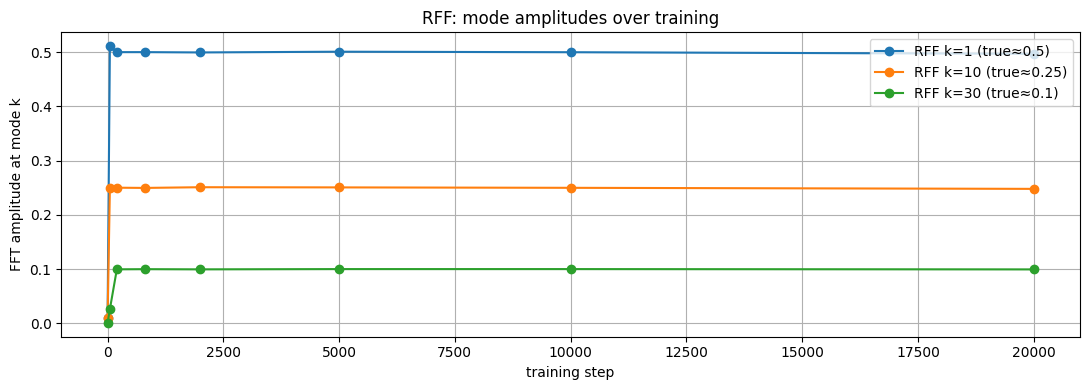

In [47]:
amps_r = {kk: [mode_amp(snap_fft_r[t][1], kk) for t in checkpoints] for kk in modes}

plt.figure(figsize=(11, 4))
for kk in modes:
    plt.plot(times, amps_r[kk], marker="o", label=f"RFF k={kk} (true≈{amp_true[kk]:.3g})")
plt.title("RFF: mode amplitudes over training")
plt.xlabel("training step")
plt.ylabel("FFT amplitude at mode k")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Data distribution
The accuracy of the learned model depends significantly on the data distribution for the training set.

1. Without any prior knowledge, uniform samples are often used for PINN.
2. A better model is often obtained by adapt the data distribution with respect to the learned approximate solution.

We demonstrate it by approximating the following function:
$$
f(x)=\frac{1}{1+a^2x^2},\quad x\in[-1,1].
$$

We consider two cases:
1. Uniform samples are fixed for the whole training process.
2. Samples from a mixture of uniform and Cauchy distributions. We start with more uniform samples and gradually increase the percentage of Cauchy samples. 


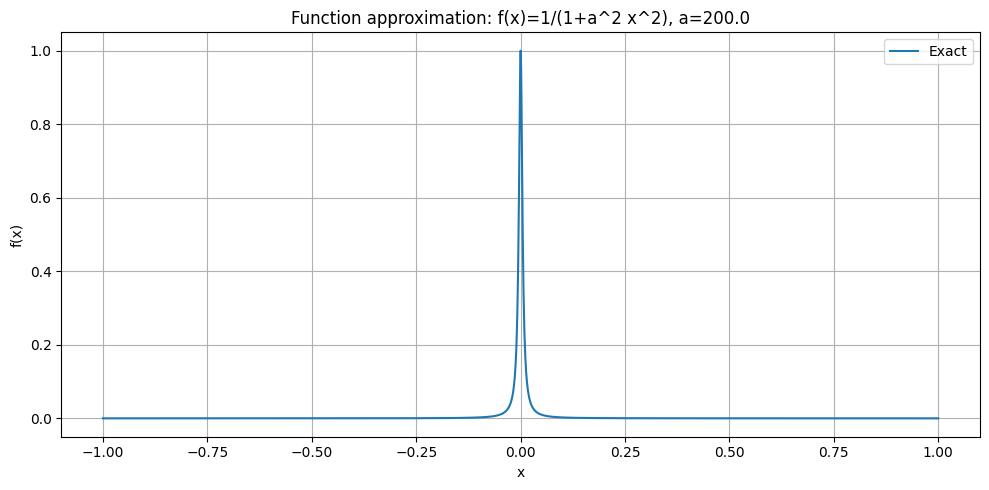

In [48]:
# ----------------------------
# Target function
# ----------------------------
a = 200.0                 # <-- try 10, 50, 100 to see sampling effects

def f_target2(x):
    # x: (N,1)
    return 1.0 / (1.0 + (a * x) ** 2)
    
x = torch.linspace(-1.0, 1.0, 2001, device=device).view(-1, 1)
y = f_target2(x)

x_np = x.detach().cpu().numpy().squeeze()
y_np = y.detach().cpu().numpy().squeeze()

plt.figure(figsize=(10, 5))
plt.plot(x_np, y_np, label="Exact")
plt.title(f"Function approximation: f(x)=1/(1+a^2 x^2), a={a}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
batch_size = 256
steps = 5000

# For adaptive sampler (mixture)
# Cauchy scale: smaller -> more concentrated around 0
cauchy_scale = 1.0 / a

# ----------------------------
# Sampling utilities
# ----------------------------
def sample_uniform(n, device):
    # Uniform on [-1,1]
    return -1.0 + 2.0 * torch.rand(n, 1, device=device)

def sample_cauchy_truncated(n, device, scale):
    """
    Sample from Cauchy(loc=0, scale=scale) truncated to [-1,1]
    via rejection sampling.
    """
    dist = torch.distributions.Cauchy(loc=torch.tensor(0.0, device=device),
                                      scale=torch.tensor(scale, device=device))
    xs = []
    need = n
    # Rejection loop (usually fast for reasonable scale)
    while need > 0:
        cand = dist.sample((need * 2, 1))  # oversample to reduce loops
        cand = cand[(cand >= -1.0) & (cand <= 1.0)].view(-1, 1)
        if cand.numel() == 0:
            continue
        take = min(need, cand.shape[0])
        xs.append(cand[:take])
        need -= take
    return torch.cat(xs, dim=0)

def sampler_uniform(step):
    return sample_uniform(batch_size, device)

def sampler_adaptive_mixture(step):
    """
    Adaptive mixture of Uniform + Cauchy.
    Simple schedule: start more uniform, gradually emphasize Cauchy.

    p_cauchy(step) ramps from 0.1 -> 0.9 over training.
    """
    p0, p1 = 0.1, 0.9
    p = p0 + (p1 - p0) * (step / steps)
    p = float(max(0.0, min(1.0, p)))

    n_c = int(round(batch_size * p))
    n_u = batch_size - n_c

    xu = sample_uniform(n_u, device)
    xc = sample_cauchy_truncated(n_c, device, scale=cauchy_scale)
    x = torch.cat([xu, xc], dim=0)

    # shuffle to mix
    idx = torch.randperm(batch_size, device=device)
    return x[idx]

In [50]:
# ----------------------------
# Training routine
# ----------------------------
def train_model(name, sampler_fn):
    model = MLP(hidden=64, depth=4).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for it in range(1, steps + 1):
        x = sampler_fn(it)
        y = f_target2(x)

        pred = model(x)
        loss = torch.mean((pred - y) ** 2)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if it % print_every == 0 or it == 1:
            print(f"[{name}] iter {it:5d} | loss = {loss.item():.3e}")

    return model

In [51]:
# ----------------------------
# Train both models
# ----------------------------
model_u = train_model("Uniform", sampler_uniform)
model_a = train_model("Adaptive(U+Cauchy)", sampler_adaptive_mixture)

[Uniform] iter     1 | loss = 1.905e-02
[Uniform] iter   500 | loss = 2.065e-03
[Uniform] iter  1000 | loss = 3.753e-03
[Uniform] iter  1500 | loss = 2.532e-03
[Uniform] iter  2000 | loss = 1.667e-03
[Uniform] iter  2500 | loss = 9.732e-04
[Uniform] iter  3000 | loss = 5.709e-04
[Uniform] iter  3500 | loss = 1.381e-04
[Uniform] iter  4000 | loss = 3.968e-05
[Uniform] iter  4500 | loss = 1.839e-05
[Uniform] iter  5000 | loss = 5.946e-06
[Adaptive(U+Cauchy)] iter     1 | loss = 5.189e-02
[Adaptive(U+Cauchy)] iter   500 | loss = 8.193e-03
[Adaptive(U+Cauchy)] iter  1000 | loss = 9.713e-04
[Adaptive(U+Cauchy)] iter  1500 | loss = 8.259e-05
[Adaptive(U+Cauchy)] iter  2000 | loss = 8.575e-05
[Adaptive(U+Cauchy)] iter  2500 | loss = 5.837e-05
[Adaptive(U+Cauchy)] iter  3000 | loss = 4.661e-05
[Adaptive(U+Cauchy)] iter  3500 | loss = 2.839e-06
[Adaptive(U+Cauchy)] iter  4000 | loss = 1.571e-05
[Adaptive(U+Cauchy)] iter  4500 | loss = 1.041e-04
[Adaptive(U+Cauchy)] iter  5000 | loss = 6.701e-06

In [30]:
# ----------------------------
# Evaluation on a uniform grid
# ----------------------------
model_u.eval()
model_a.eval()

with torch.no_grad():
    xg = torch.linspace(-1.0, 1.0, 2001, device=device).view(-1, 1)
    yg = f_target2(xg)

    yu = model_u(xg)
    ya = model_a(xg)

    err_u = torch.abs(yu - yg)
    err_a = torch.abs(ya - yg)

    max_u = err_u.max().item()
    max_a = err_a.max().item()
    l2_u = torch.sqrt(torch.mean((yu - yg) ** 2)).item()
    l2_a = torch.sqrt(torch.mean((ya - yg) ** 2)).item()

print("\n=== Evaluation on grid ===")
print(f"Uniform:   L2 = {l2_u:.3e},  max = {max_u:.3e}")
print(f"Adaptive:  L2 = {l2_a:.3e},  max = {max_a:.3e}")



=== Evaluation on grid ===
Uniform:   L2 = 3.405e-03,  max = 5.136e-02
Adaptive:  L2 = 1.201e-03,  max = 4.875e-03


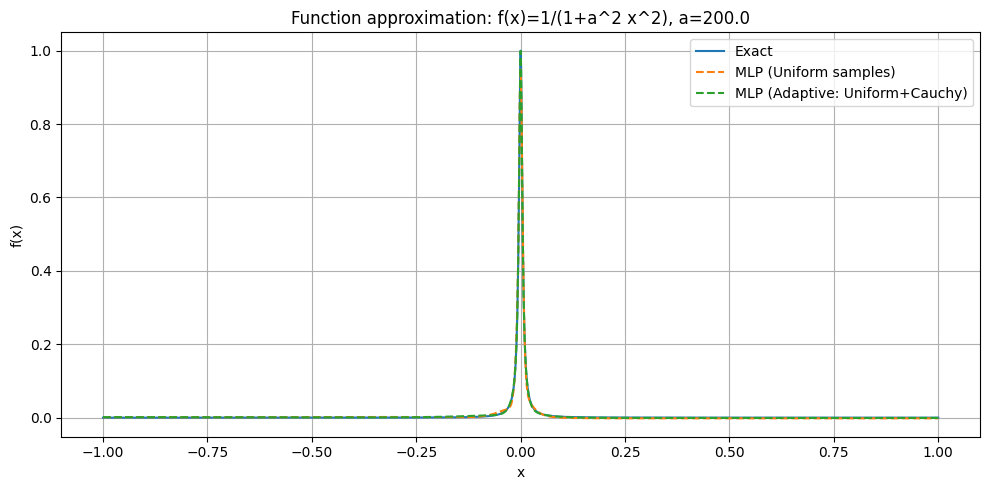

In [31]:
# ----------------------------
# Plots
# ----------------------------
x_np = xg.detach().cpu().numpy().squeeze()
y_np = yg.detach().cpu().numpy().squeeze()
yu_np = yu.detach().cpu().numpy().squeeze()
ya_np = ya.detach().cpu().numpy().squeeze()
eu_np = err_u.detach().cpu().numpy().squeeze()
ea_np = err_a.detach().cpu().numpy().squeeze()

plt.figure(figsize=(10, 5))
plt.plot(x_np, y_np, label="Exact")
plt.plot(x_np, yu_np, linestyle="--", label="MLP (Uniform samples)")
plt.plot(x_np, ya_np, linestyle="--", label="MLP (Adaptive: Uniform+Cauchy)")
plt.title(f"Function approximation: f(x)=1/(1+a^2 x^2), a={a}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

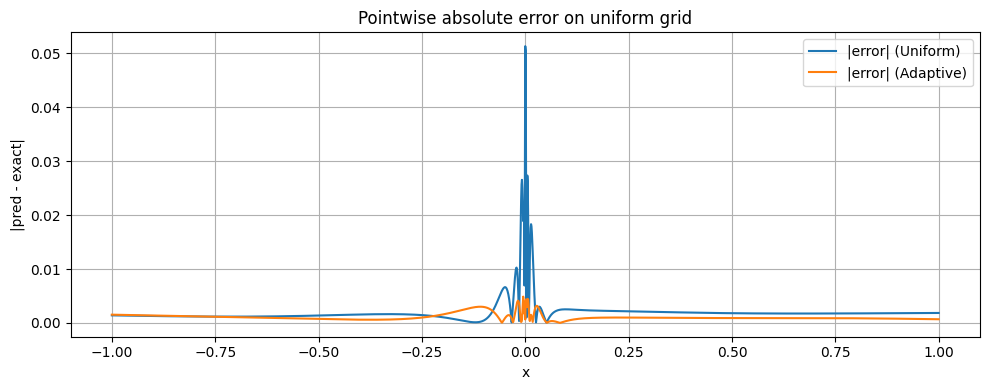

In [32]:
plt.figure(figsize=(10, 4))
plt.plot(x_np, eu_np, label="|error| (Uniform)")
plt.plot(x_np, ea_np, label="|error| (Adaptive)")
plt.title("Pointwise absolute error on uniform grid")
plt.xlabel("x")
plt.ylabel("|pred - exact|")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()